In [4]:
import pandas as pd
import numpy as np

import datetime as dt

from pathlib import Path 

In [5]:
# =========== PATHs =========== #
PATH_ATUAL = Path(__vsc_ipynb_file__).parent  # 2.SCRIPTS
PATH_DADOS = PATH_ATUAL.parent / "1.DADOS/1.2.DADOS_REFINADOS"

In [6]:
df_IPCA = pd.read_csv(PATH_DADOS/"IPCA_CONSOLIDADO.csv", sep = ";", encoding = "utf-8")
df_IPCA.head()

,CATEGORIA_COD,CATEGORIA,CODIGO,NOME_ATIVO_BRUTO,NOME_ATIVO,CATEGORIA_TIPO,COMPLETUDE_INFO,ANO_COD,MES_COD,MES,IPCA_VAR_MENSAL,IPCA_PESO_MENSAL,IPCA_VAR_12M,IPCA_VAR_YTD
0,2640,Índice geral,0,Índice geral,Índice geral,GERAL,COMPLETA,1991,199101,janeiro 1991,21.09,NaN,NaN,NaN
1,2640,Índice geral,0,Índice geral,Índice geral,GERAL,COMPLETA,1991,199102,fevereiro 1991,22.86,NaN,NaN,NaN
2,2640,Índice geral,0,Índice geral,Índice geral,GERAL,COMPLETA,1991,199103,março 1991,14.11,NaN,NaN,NaN
3,2640,Índice geral,0,Índice geral,Índice geral,GERAL,COMPLETA,1991,199104,abril 1991,4.63,NaN,NaN,NaN
4,2640,Índice geral,0,Índice geral,Índice geral,GERAL,COMPLETA,1991,199105,maio 1991,7.76,NaN,NaN,NaN


In [27]:
def var_acumulada(janela_temporal):
    return (np.prod((1 + janela_temporal/100)) - 1)*100

df_IPCA["CALC_IPCA_VAR_12M"] = df_IPCA.groupby(by = "CODIGO", as_index = False)["IPCA_VAR_MENSAL"].rolling(window = 12, min_periods = 1).apply(var_acumulada, raw = True)["IPCA_VAR_MENSAL"]
df_IPCA["CALC_IPCA_VAR_ANO"] = df_IPCA.groupby(by = ["CODIGO", "ANO_COD"], as_index = False)["IPCA_VAR_MENSAL"].rolling(window = 12, min_periods = 1).apply(var_acumulada, raw = True)["IPCA_VAR_MENSAL"]

In [28]:
df_IPCA.head(n = 10000)

,CATEGORIA_COD,CATEGORIA,CODIGO,NOME_ATIVO_BRUTO,NOME_ATIVO,CATEGORIA_TIPO,COMPLETUDE_INFO,ANO_COD,MES_COD,MES,IPCA_VAR_MENSAL,IPCA_PESO_MENSAL,IPCA_VAR_12M,IPCA_VAR_YTD,CALC_IPCA_VAR12M,CALC_IPCA_VAR_12M,CALC_IPCA_VAR_ANO
0,2640,Índice geral,0,Índice geral,Índice geral,GERAL,COMPLETA,1991,199101,janeiro 1991,21.09,NaN,NaN,NaN,21.090000,21.090000,21.090000
1,2640,Índice geral,0,Índice geral,Índice geral,GERAL,COMPLETA,1991,199102,fevereiro 1991,22.86,NaN,NaN,NaN,48.771174,48.771174,48.771174
2,2640,Índice geral,0,Índice geral,Índice geral,GERAL,COMPLETA,1991,199103,março 1991,14.11,NaN,NaN,NaN,69.762787,69.762787,69.762787
3,2640,Índice geral,0,Índice geral,Índice geral,GERAL,COMPLETA,1991,199104,abril 1991,4.63,NaN,NaN,NaN,77.622804,77.622804,77.622804
4,2640,Índice geral,0,Índice geral,Índice geral,GERAL,COMPLETA,1991,199105,maio 1991,7.76,NaN,NaN,NaN,91.406333,91.406333,91.406333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,7202,1103003.Batata-inglesa,1103003,Batata-inglesa,Batata-inglesa,SUBITEM,COMPLETA,2017,201702,fevereiro 2017,-1.88,0.1363,-36.49,-11.82,-36.493113,-36.493113,-11.829368
9996,7202,1103003.Batata-inglesa,1103003,Batata-inglesa,Batata-inglesa,SUBITEM,COMPLETA,2017,201703,março 2017,1.92,0.1333,-39.85,-10.14,-39.845521,-39.845521,-10.136492
9997,7202,1103003.Batata-inglesa,1103003,Batata-inglesa,Batata-inglesa,SUBITEM,COMPLETA,2017,201704,abril 2017,23.96,0.1355,-25.15,11.40,-25.148070,-25.148070,11.394805
9998,7202,1103003.Batata-inglesa,1103003,Batata-inglesa,Batata-inglesa,SUBITEM,COMPLETA,2017,201705,maio 2017,-1.67,0.1677,-41.62,9.54,-41.618226,-41.618226,9.534511


## Série temporal: variação mensal do IPCA (Geral e Grupos)

Vamos fazer o **mesmo gráfico** em três motores gráficos diferentes — matplotlib, seaborn e plotly — pra comparar sintaxe. Você já conhece `ggplot`/`ggplot2` (grammar of graphics: `data + aes(x, y, color) + geom_*()`), então a referência vai ser sempre essa.

Primeiro, prep dos dados: filtrar `CATEGORIA_TIPO` em `GERAL`/`GRUPO` e converter `MES_COD` (formato `yyyymm`) pra `datetime`, que é o que os três motores esperam num eixo temporal.

In [12]:
df_plot = df_IPCA[df_IPCA["CATEGORIA_TIPO"].isin(["GERAL", "GRUPO"])].copy()
df_plot["DATA"] = pd.to_datetime(df_plot["MES_COD"], format="%Y%m")
df_plot = df_plot.sort_values("DATA")

print(df_plot["NOME_ATIVO"].unique())
df_plot[["NOME_ATIVO", "DATA", "IPCA_VAR_MENSAL"]].head()

['Alimentação e bebidas' 'Habitação' 'Índice geral']


,NOME_ATIVO,DATA,IPCA_VAR_MENSAL
0,Alimentação e bebidas,1991-01-01,21.27
2346,Habitação,1991-01-01,26.62
22542,Índice geral,1991-01-01,21.09
22543,Índice geral,1991-02-01,22.86
1,Alimentação e bebidas,1991-02-01,16.36


### 1. Matplotlib — imperativo

Matplotlib **não tem** `aes()`. Não existe mapeamento declarativo de coluna → estética: você mesmo itera sobre os grupos e desenha uma linha (`ax.plot`) por vez. É o motor mais baixo nível — mais controle, mais código.

- `fig, ax = plt.subplots()` ≈ abrir a "folha" antes de desenhar (não tem equivalente direto no ggplot, que já cria a folha implicitamente)
- `ax.plot(x, y, label=...)` ≈ um `geom_line()` manual, chamado uma vez por série
- `ax.legend()`, `ax.set_xlabel()` ≈ os `+ labs()` / `+ theme()` do ggplot, só que cada elemento é uma chamada separada

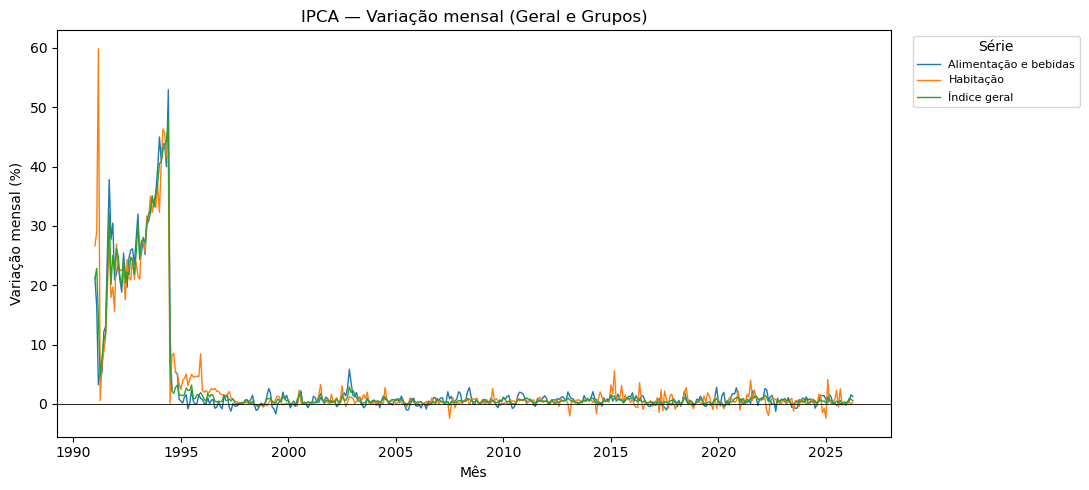

In [13]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(11, 5))

# Cada série (Geral + cada grupo) vira um ax.plot() separado — sem mapeamento automático de cor.
for nome, serie in df_plot.groupby("NOME_ATIVO"):
    ax.plot(serie["DATA"], serie["IPCA_VAR_MENSAL"], label=nome, linewidth=1)

ax.axhline(0, color="black", linewidth=0.6)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.set_title("IPCA — Variação mensal (Geral e Grupos)")
ax.set_xlabel("Mês")
ax.set_ylabel("Variação mensal (%)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8, title="Série")

fig.tight_layout()
plt.show()

### 2. Seaborn — estatístico, construído sobre matplotlib

Aqui a sintaxe já fica **quase igual ao ggplot**: uma função por tipo de geometria (`lineplot` ≈ `geom_line`, `scatterplot` ≈ `geom_point`, `barplot` ≈ `geom_col`), e o mapeamento estética é feito por parâmetros nomeados em vez de `aes()`:

| ggplot | seaborn |
|---|---|
| `ggplot(df, aes(x, y, color=grupo))` | `sns.lineplot(data=df, x=..., y=..., hue=grupo)` |
| `+ geom_line()` | (já embutido em `lineplot`) |
| `+ labs(title=...)` | `plt.title(...)` (seaborn devolve o controle pro matplotlib pra isso) |

Ou seja: seaborn cuida do **mapeamento dado → estética** (a parte que mais lembra ggplot), mas delega **eixos, títulos e composição da figura** de volta pro matplotlib.

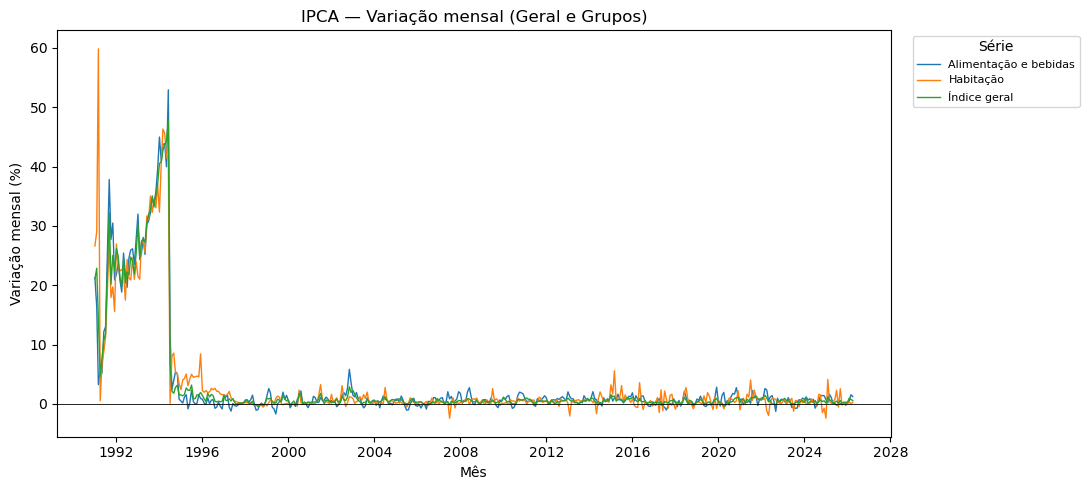

In [14]:
import seaborn as sns

plt.figure(figsize=(11, 5))

# data= + x= + y= + hue= é o equivalente direto de data + aes(x, y, color=) no ggplot.
sns.lineplot(data=df_plot, x="DATA", y="IPCA_VAR_MENSAL", hue="NOME_ATIVO", linewidth=1)

plt.axhline(0, color="black", linewidth=0.6)
plt.title("IPCA — Variação mensal (Geral e Grupos)")
plt.xlabel("Mês")
plt.ylabel("Variação mensal (%)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, title="Série")

plt.tight_layout()
plt.show()

### 3. Plotly Express — declarativo e interativo

`plotly.express` é o que chega **mais perto do ggplot em formato de chamada**: uma função só, recebendo o dataframe e os nomes das colunas — nada de loop, nada de objeto `fig, ax` pra gerenciar antes. A diferença é que o resultado é interativo (zoom, pan, hover) em vez de uma imagem estática.

```
ggplot(df, aes(x=DATA, y=IPCA_VAR_MENSAL, color=NOME_ATIVO)) + geom_line()
```
```
px.line(df, x="DATA", y="IPCA_VAR_MENSAL", color="NOME_ATIVO")
```

Praticamente uma tradução 1:1. `labels=` substitui o `+ labs()`, e customizações finas (fonte da legenda, etc.) vão em `fig.update_layout(...)`.

In [15]:
import plotly.express as px

fig = px.line(
    df_plot,
    x="DATA",
    y="IPCA_VAR_MENSAL",
    color="NOME_ATIVO",
    title="IPCA — Variação mensal (Geral e Grupos)",
    labels={
        "DATA": "Mês",
        "IPCA_VAR_MENSAL": "Variação mensal (%)",
        "NOME_ATIVO": "Série",
    },
)
fig.add_hline(y=0, line_color="black", line_width=0.6)
fig.update_layout(legend=dict(font=dict(size=9)))
fig.show()

### Resumo

| | Matplotlib | Seaborn | Plotly Express |
|---|---|---|---|
| Paradigma | imperativo | declarativo (dados→estética), imperativo (resto) | declarativo |
| Mapeamento cor/grupo | manual (`for` + `.plot`) | `hue=` | `color=` |
| Saída | estática | estática | interativa |
| Mais parecido com ggplot | pouco | moderado | muito |

Não instalei, mas existe também o **[plotnine](https://plotnine.org/)**: um porte *literal* do ggplot2 pro Python — mesma sintaxe `ggplot(df) + aes(x=, y=, color=) + geom_line()`, `+` de camadas e tudo. Se quiser a transição mais direta possível (copiar seu conhecimento de `ggplot` quase sem tradução), me avisa que eu instalo (`pip install plotnine`) e refaço esse mesmo gráfico nele.